**M4 Daily Time Series: Comparative Analysis of ES-RNN vs. LightGBM**
- Uses a SINGLE pre-calculated CSV containing all metrics, correlation, winner, and trend.
- Analyzes the relationship between trend and forecast performance/correlation.
- Performs statistical tests.
- Generates visualizations.

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import warnings

# Configure plotting style and font
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']
rcParams['font.size'] = 12
sns.set_style("whitegrid")


# --- Define Paths ---
DATA_PATH = "/kaggle/input/m4-competiton-coparative-analysis/" 
ANALYSIS_FILE = DATA_PATH + "analysis_df.csv"

# --- Load Data ---
try:
    analysis_df = pd.read_csv(ANALYSIS_FILE)
    if 'Unnamed: 0' in analysis_df.columns:
        analysis_df = analysis_df.drop(columns=['Unnamed: 0'])
    if 'new_trend_Acomulada' in analysis_df.columns:
        analysis_df = analysis_df.rename(columns={'new_trend_Acomulada': 'trend'})
    elif 'trend' not in analysis_df.columns:
        raise ValueError("Trend column ('new_trend_Acomulada' or 'trend') not found.")

    required_cols = [ 'serie', 'sMAPE_ESRNN', 'MAE_ESRNN', 'MAPE_ESRNN', 'RMSE_ESRNN', 'sMAPE_LGBM', 'MAE_LGBM', 'MAPE_LGBM', 'RMSE_LGBM', 'correlation', 'winner', 'trend']
    if not all(col in analysis_df.columns for col in required_cols):
        missing = [col for col in required_cols if col not in analysis_df.columns]
        raise ValueError(f"Combined analysis file is missing required columns: {missing}")

    print(f"Successfully loaded combined analysis data. Shape: {analysis_df.shape}")
    print(analysis_df.head())

except FileNotFoundError as e:
    print(f"Error: Combined analysis file not found at {ANALYSIS_FILE}")
    analysis_df = pd.DataFrame()
except Exception as e:
    print(f"An error occurred loading/checking the combined data: {e}")
    analysis_df = pd.DataFrame()

Successfully loaded combined analysis data. Shape: (2724, 12)
  serie  sMAPE_ESRNN    MAE_ESRNN  MAPE_ESRNN   RMSE_ESRNN  sMAPE_LGBM  \
0    D1     1.296944    26.603170    1.287552    28.242924   19.341024   
1    D2     0.928656    27.900714    0.919856    40.549106    1.257448   
2    D6     5.118614   164.396068    4.964824   182.004938   54.112424   
3    D7    31.607398  1918.778455   30.133036  2171.008056   42.528841   
4    D8     0.489877     8.540982    0.491425    11.456555   12.149051   

      MAE_LGBM  MAPE_LGBM    RMSE_LGBM  correlation  winner  trend  
0   363.636183  17.634031   363.877524     0.831126       0      7  
1    37.791939   1.256516    44.248545     0.628759       0      5  
2  1394.508458  42.572966  1397.487947     0.568809       0      3  
3  2475.482484  34.980921  2811.356992    -0.014365       0     -1  
4   199.264105  11.452574   199.400044    -0.112225       0     -1  


In [3]:
# # 2. Analysis and Visualization (Using Combined Data)



def create_histogram_by_winner(df, title):
    """
    Creates a histogram of correlation values split by winner model.
    Assumes df has 'correlation' and 'winner' columns (0=ESRNN, 1=LGBM).
    """
    if 'correlation' not in df.columns or 'winner' not in df.columns:
        print("Error: DataFrame must contain 'correlation' and 'winner' columns.")
        return None

    # Drop NaNs in correlation for accurate plotting and stats
    df_plot = df.dropna(subset=['correlation'])

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))

    # Split data by winner
    lgbm_corr = df_plot[df_plot['winner'] == 1]['correlation']
    esrnn_corr = df_plot[df_plot['winner'] == 0]['correlation']

    # Create histogram bins
    bins = np.linspace(-1, 1, 21)  # 20 bins from -1 to 1

    # Plot histograms
    ax.hist(lgbm_corr, bins=bins, alpha=0.7, label='LightGBM', color='#6790f0') # Blue for LGBM wins
    ax.hist(esrnn_corr, bins=bins, alpha=0.7, label='ES-RNN', color='#c3d7e3') # Light blue/grey for ESRNN wins

    # Add labels and title
    ax.set_xlabel('Winning Model Correlation with Actuals', fontsize=14)
    ax.set_ylabel('Frequency', fontsize=14)
    ax.set_title(title if title else 'Distribution of Winning Model Correlation', fontsize=16)
    ax.legend(prop={'family': 'DejaVu Serif', 'size': 11})

    # Add grid
    ax.grid(True, linestyle='--', alpha=0.7)

    # Add text with summary statistics
    lgbm_n = len(lgbm_corr)
    esrnn_n = len(esrnn_corr)
    lgbm_mean = lgbm_corr.mean() if lgbm_n > 0 else np.nan
    esrnn_mean = esrnn_corr.mean() if esrnn_n > 0 else np.nan

    lgbm_stats = f"LightGBM Wins: n={lgbm_n}, mean={lgbm_mean:.2f}"
    esrnn_stats = f"ES-RNN Wins: n={esrnn_n}, mean={esrnn_mean:.2f}"

    ax.text(0.75, 0.95, lgbm_stats, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='DejaVu Serif',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.text(0.75, 0.87, esrnn_stats, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='DejaVu Serif',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Set tick fonts
    ax.tick_params(axis='both', which='major', labelsize=11)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontname('DejaVu Serif')

    plt.tight_layout()
    return fig


Summary of Comparison between Methods (based on pre-calculated metrics):
       ES-RNN Wins  LGBM Wins  Ties  ES-RNN Win %  LGBM Win %
sMAPE       1226.0     1498.0   0.0     45.007342   54.992658
MAE         1231.0     1493.0   0.0     45.190896   54.809104
MAPE        1234.0     1490.0   0.0     45.301028   54.698972
RMSE        1262.0     1462.0   0.0     46.328928   53.671072


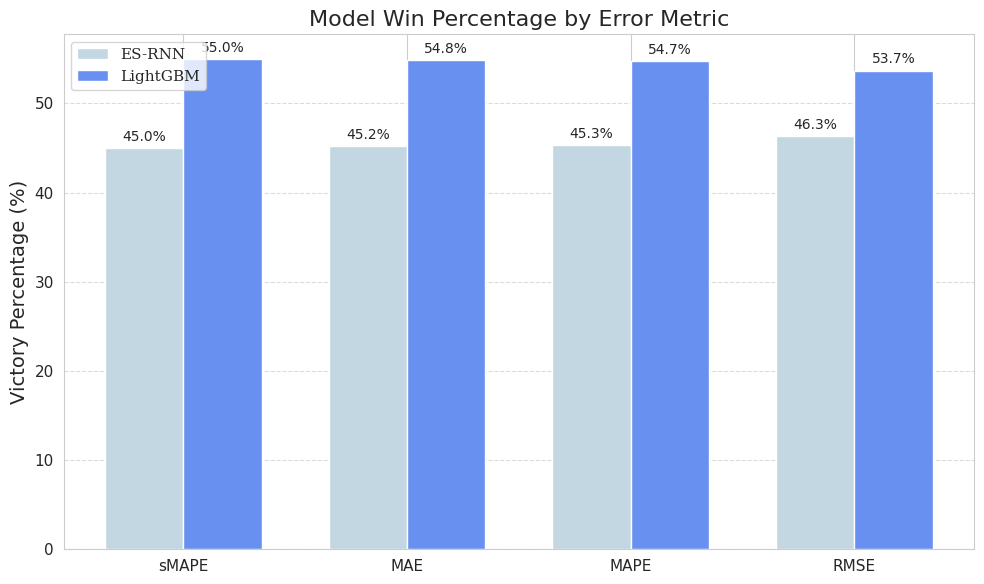

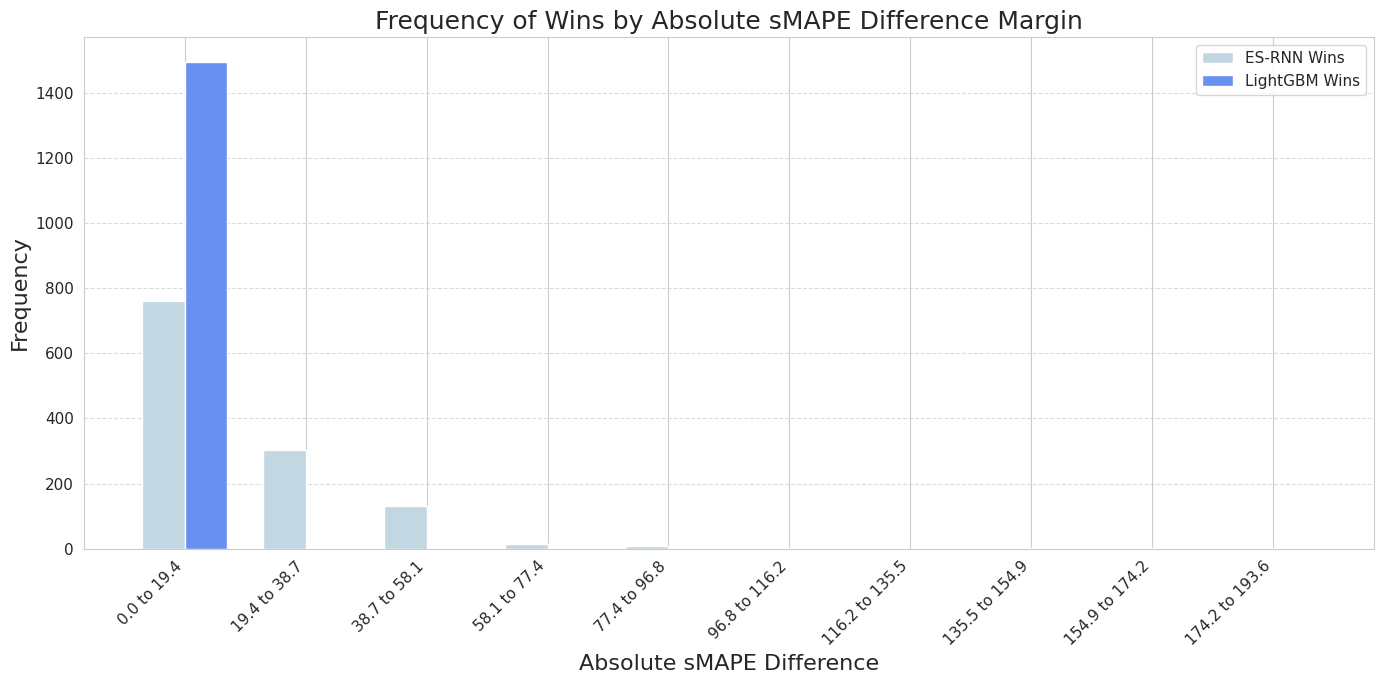


--- Correlation Distribution by Winning Model ---


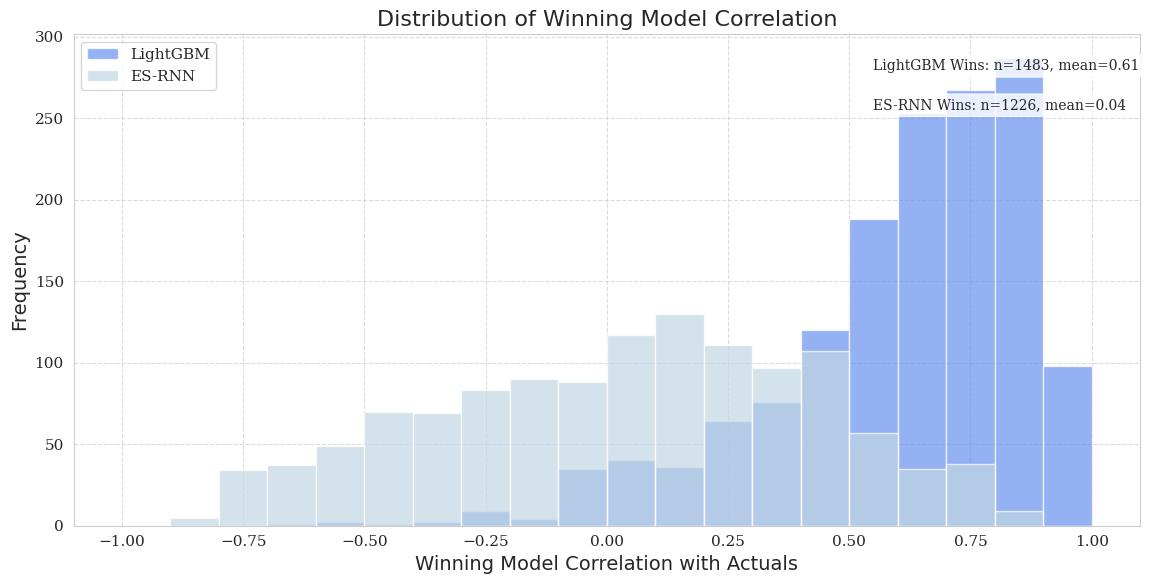


Shape for Trend/Correlation analysis after dropping NaNs: (2709, 20)


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


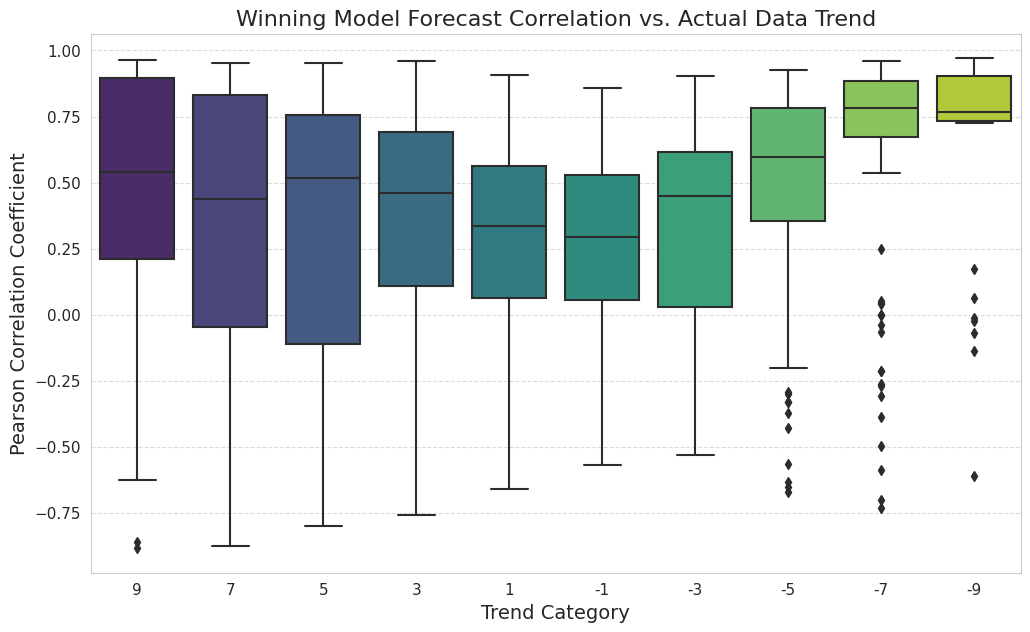

In [4]:
# --- Run Analysis and Generate Plots ---
if not analysis_df.empty:
    # --- 2a. Initial Performance Comparison (Based on Pre-loaded Metrics) ---
    metrics = ['sMAPE', 'MAE', 'MAPE', 'RMSE']
    comparison_summary = {}
    for metric in metrics:
        col_esrnn = f'{metric}_ESRNN'; col_lgbm = f'{metric}_LGBM'
        analysis_df[f'{metric}_Winner'] = np.where(analysis_df[col_esrnn] < analysis_df[col_lgbm], 'ES-RNN', np.where(analysis_df[col_lgbm] < analysis_df[col_esrnn], 'LGBM', 'Tie'))
        analysis_df[f'{metric}_Diff'] = analysis_df[col_esrnn] - analysis_df[col_lgbm]
        wins_esrnn = (analysis_df[f'{metric}_Winner'] == 'ES-RNN').sum(); wins_lgbm = (analysis_df[f'{metric}_Winner'] == 'LGBM').sum(); ties = (analysis_df[f'{metric}_Winner'] == 'Tie').sum(); total = len(analysis_df)
        percent_esrnn = wins_esrnn / total * 100 if total > 0 else 0; percent_lgbm = wins_lgbm / total * 100 if total > 0 else 0
        comparison_summary[metric] = {'ES-RNN Wins': wins_esrnn, 'LGBM Wins': wins_lgbm, 'Ties': ties, 'ES-RNN Win %': percent_esrnn, 'LGBM Win %': percent_lgbm}
    df_comparison = pd.DataFrame(comparison_summary).T
    print("\nSummary of Comparison between Methods (based on pre-calculated metrics):")
    print(df_comparison)

    # --- 2b. Visualize Win Percentages ---
    metrics_names = list(df_comparison.index); x = np.arange(len(metrics_names)); width = 0.35
    fig_winpct, ax_winpct = plt.subplots(figsize=(10, 6))
    bars_A = ax_winpct.bar(x - width/2, df_comparison['ES-RNN Win %'], width, color='#c3d7e3', label='ES-RNN')
    bars_B = ax_winpct.bar(x + width/2, df_comparison['LGBM Win %'], width, color='#6790f0', label='LightGBM')
    ax_winpct.set_ylabel('Victory Percentage (%)', fontsize=14); ax_winpct.set_xticks(x); ax_winpct.set_xticklabels(metrics_names, fontsize=12)
    ax_winpct.legend(prop={'family': 'DejaVu Serif', 'size': 11}, loc='upper left'); ax_winpct.set_title('Model Win Percentage by Error Metric', fontsize=16)
    ax_winpct.tick_params(axis='both', which='major', labelsize=11); ax_winpct.grid(axis='y', linestyle='--', alpha=0.7)
    def autolabel(bars, ax_target): # Pass axis to annotation function
      for bar in bars:
          height = bar.get_height()
          ax_target.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)
    autolabel(bars_A, ax_winpct); autolabel(bars_B, ax_winpct)
    plt.tight_layout(); plt.show()

    # --- 2c. Visualize sMAPE Difference Distribution (Absolute Difference) ---
    smape_diff = analysis_df['sMAPE_Diff']
    winner_lgbm_flag = analysis_df['winner']
    smape_diff_abs = np.abs(smape_diff)
    num_bins_total = 10
    if not smape_diff_abs.empty and not smape_diff_abs.isna().all():
        max_abs_diff = smape_diff_abs.max(); max_abs_diff = max(max_abs_diff, 1)
        bins = np.linspace(0, max_abs_diff, num_bins_total + 1)
        y_rnn_wins_counts = []; y_lgbm_wins_counts = []
        for i in range(len(bins) - 1):
            lower = bins[i]; upper = bins[i+1]
            mask = (smape_diff_abs >= lower) & (smape_diff_abs < upper) if i < len(bins) - 2 else (smape_diff_abs >= lower) & (smape_diff_abs <= upper)
            y_rnn_wins_counts.append((mask & (winner_lgbm_flag == 0)).sum()); y_lgbm_wins_counts.append((mask & (winner_lgbm_flag == 1)).sum())
        x_abs = np.arange(len(bins) - 1); labels_abs = [f'{bins[i]:.1f} to {bins[i+1]:.1f}' for i in range(len(bins) - 1)]
        fig_abs, ax_abs = plt.subplots(figsize=(14, 7))
        rects1_abs = ax_abs.bar(x_abs - width/2, y_rnn_wins_counts, width, label='ES-RNN Wins', color='#c3d7e3')
        rects2_abs = ax_abs.bar(x_abs + width/2, y_lgbm_wins_counts, width, label='LightGBM Wins', color='#6790f0')
        ax_abs.set_xlabel('Absolute sMAPE Difference', fontsize=16); ax_abs.set_ylabel('Frequency', fontsize=16)
        ax_abs.set_title('Frequency of Wins by Absolute sMAPE Difference Margin', fontsize=18); ax_abs.set_xticks(x_abs)
        ax_abs.set_xticklabels(labels_abs, rotation=45, ha="right", fontsize=12); ax_abs.legend(fontsize=11)
        ax_abs.grid(axis='y', linestyle='--', alpha=0.7); ax_abs.tick_params(axis='both', which='major', labelsize=11)
        plt.tight_layout(); plt.show()
    else: print("sMAPE difference data is empty or invalid for histogram plotting.")

    # --- 2d. Visualize Correlation Distribution by Winner ---
    # Filter NaNs from correlation before plotting
    analysis_df_corr_filtered = analysis_df.dropna(subset=['correlation'])
    if not analysis_df_corr_filtered.empty:
         print("\n--- Correlation Distribution by Winning Model ---")
         fig_corr_hist = create_histogram_by_winner(analysis_df_corr_filtered, '') # Use the function
         plt.show()
    else:
         print("\nCorrelation data contains too many NaNs for histogram.")


    # --- 2e. Trend vs. Correlation Analysis ---
    analysis_df_filtered = analysis_df.dropna(subset=['correlation', 'trend']).copy()
    print(f"\nShape for Trend/Correlation analysis after dropping NaNs: {analysis_df_filtered.shape}")
    if not analysis_df_filtered.empty:
        # --- Boxplot ---
        boxplot_data = analysis_df_filtered[(analysis_df_filtered['trend'] >= -9) & (analysis_df_filtered['trend'] <= 9)].copy()
        boxplot_data['trend'] = pd.to_numeric(boxplot_data['trend'], errors='coerce')
        boxplot_data = boxplot_data.dropna(subset=['trend'])
        if not boxplot_data.empty:
            boxplot_data['trend'] = pd.Categorical(boxplot_data['trend'], categories=sorted(boxplot_data['trend'].unique(), reverse=True), ordered=True)
            plt.figure(figsize=(12, 7)); sns.boxplot(x='trend', y='correlation', data=boxplot_data, palette='viridis')
            plt.title('Winning Model Forecast Correlation vs. Actual Data Trend', fontsize=16); plt.xlabel('Trend Category', fontsize=14)
            plt.ylabel('Pearson Correlation Coefficient', fontsize=14); plt.xticks(fontsize=11); plt.yticks(fontsize=11)
            plt.grid(axis='y', linestyle='--', alpha=0.7); plt.show()
        else: print("No data available for boxplot after filtering trends -9 to +9.")

        

    else:
        print("No data available for Trend vs Correlation analysis after filtering NaNs.")

else:
    print("Initial data loading/merging failed. Analysis cannot proceed.")